# Capítulo 3 – Modelo Base de Regresión Lineal Múltiple
## Sistema de Bicicletas Compartidas – Dataset `hour_prepared.csv`

En este capítulo ajustamos un **primer modelo base de regresión lineal múltiple** para explicar la demanda horaria de bicicletas (`cnt`) a partir de las variables preparadas en el Capítulo 2.

Trabajaremos con el dataset ya transformado y con variables dummies, almacenado en `../data/hour_prepared.csv`.


## 1. Carga de librerías y datos

Cargamos el dataset preparado y separamos la variable objetivo `cnt` de los predictores.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


In [14]:
# Carga del dataset preparado
data_path = "../data/hour_prepared.csv"
df_model = pd.read_csv(data_path)

df_model.head()

,temp,atemp,hum,windspeed,peak_hour,hr_1,hr_2,hr_3,hr_4,hr_5,...,weekday_6,workingday_1,season_2,season_3,season_4,yr_1,weathersit_2,weathersit_3,weathersit_4,cnt
0,0.24,0.2879,0.81,0.0,0,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,16
1,0.22,0.2727,0.80,0.0,0,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,40
2,0.22,0.2727,0.80,0.0,0,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,32
3,0.24,0.2879,0.75,0.0,0,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,13
4,0.24,0.2879,0.75,0.0,0,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,1


Verificamos dimensiones y presencia de valores faltantes:


In [15]:
df_model.shape

(17379, 43)

In [16]:
df_model.isna().sum().sum()

np.int64(0)

## 2. Definición de la variable objetivo y predictores

Definimos:

- Variable objetivo: `cnt`.
- Matriz de predictores: todas las demás columnas del dataset preparado.


In [17]:
target_col = "cnt"
if target_col not in df_model.columns:
    raise ValueError("La columna 'cnt' no se encuentra en 'hour_prepared.csv'.")

y = df_model["cnt"].astype(float)
X = df_model.drop(columns=["cnt"])

X = X.select_dtypes(include=["number"]).astype(float)

X.dtypes.head(), y.shape

(temp         float64
 atemp        float64
 hum          float64
 windspeed    float64
 peak_hour    float64
 dtype: object,
 (17379,))

## 3. Partición en conjuntos de entrenamiento y prueba

Dividimos los datos en:

- **Entrenamiento**: 80%
- **Prueba**: 20%

Utilizamos una semilla fija (`random_state=123`) para garantizar reproducibilidad.


In [18]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

X_train.shape, X_test.shape

((13903, 5), (3476, 5))

## 4. Ajuste del modelo OLS (mínimos cuadrados ordinarios)

Para utilizar `statsmodels`, añadimos un término de intercepto (`const`) a la matriz de diseño y ajustamos un modelo OLS sobre el conjunto de entrenamiento.


In [19]:
# Añadimos constante a los predictores
X_train_const = sm.add_constant(X_train, has_constant="add")
X_test_const  = sm.add_constant(X_test,  has_constant="add")

X_train_const.head()

,const,temp,atemp,hum,windspeed,peak_hour
2837,1.0,0.54,0.5152,0.83,0.2836,0.0
15553,1.0,0.56,0.5303,0.73,0.2985,0.0
1931,1.0,0.18,0.1818,0.55,0.1940,0.0
5233,1.0,0.74,0.6515,0.37,0.0896,0.0
11900,1.0,0.58,0.5455,0.88,0.1343,0.0


In [20]:
# Ajuste del modelo OLS en el conjunto de entrenamiento
ols = sm.OLS(y_train, X_train_const).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     2293.
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        01:40:52   Log-Likelihood:                -87821.
No. Observations:               13903   AIC:                         1.757e+05
Df Residuals:                   13897   BIC:                         1.757e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.0733      6.250     19.212      0.000     107.823     132.324
temp          61.2861     40.274      1.522      0.128     -17.656     140.229
atemp        340.4978     45.201      7.533      0.000     251.899     429.097
hum         -273.4382      6.176    -44.276      0.000    -285.543    -261.333
windspeed      9.5407     10.030      0.951      0.341     -10.119      29.200
peak_hour    184.7146      2.622     70.437      0.000     179.574     189.855
==============================================================================
Omnibus:                     1672.276   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2797.170
Skew:                           0.831   Prob(JB):                         0.00
Kurtosis:                       4.438   Cond. No.                         75.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 4.1. Resumen del modelo

Mostramos el resumen estándar de `statsmodels`, que incluye estimaciones de coeficientes, errores estándar, valores *t* y *p*-values.


In [21]:
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     2293.
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        01:40:52   Log-Likelihood:                -87821.
No. Observations:               13903   AIC:                         1.757e+05
Df Residuals:                   13897   BIC:                         1.757e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.0733      6.250     19.212      0.000     107.823     132.324
temp          61.2861     40.274      1.522      0.128     -17.656     140.229
atemp        340.4978     45.201      7.533      0.000     251.899     429.097
hum         -273.4382      6.176    -44.276      0.000    -285.543    -261.333
windspeed      9.5407     10.030      0.951      0.341     -10.119      29.200
peak_hour    184.7146      2.622     70.437      0.000     179.574     189.855
==============================================================================
Omnibus:                     1672.276   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2797.170
Skew:                           0.831   Prob(JB):                         0.00
Kurtosis:                       4.438   Cond. No.                         75.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 4.2. Tabla de coeficientes en formato tabular

Construimos una tabla con:

- Coeficientes estimados (`coef`).
- Errores estándar (`std err`).
- Estadístico t (`t`).
- Valor-p (`P>|t|`).
- Intervalos de confianza al 95% (`IC 2.5%`, `IC 97.5%`).


In [22]:
conf_int = ols.conf_int(alpha=0.05)

# Aseguramos que conf_int tenga nombres de columnas claros
conf_int.columns = ["IC 2.5%", "IC 97.5%"]

# Construimos la tabla de coeficientes como DataFrame
coef_table = pd.DataFrame({
    "coef": ols.params,
    "std err": ols.bse,
    "t": ols.tvalues,
    "P>|t|": ols.pvalues,
})

coef_table = pd.concat([coef_table, conf_int], axis=1)
coef_table.index.name = "Parámetro"
coef_table.round(4)

,coef,std err,t,P>|t|,IC 2.5%,IC 97.5%
Parámetro,,,,,,
const,120.0733,6.2499,19.2122,0.0000,107.8227,132.3239
temp,61.2861,40.2740,1.5217,0.1281,-17.6564,140.2287
atemp,340.4978,45.2005,7.5331,0.0000,251.8987,429.0969
hum,-273.4382,6.1757,-44.2762,0.0000,-285.5434,-261.3329
windspeed,9.5407,10.0298,0.9512,0.3415,-10.1190,29.2005
peak_hour,184.7146,2.6224,70.4371,0.0000,179.5743,189.8548


## 5. Métricas de desempeño del modelo base

Evaluamos el modelo tanto en el **conjunto de entrenamiento** como en el **conjunto de prueba**, utilizando:

- Error cuadrático medio (RMSE).
- Coeficiente de determinación (R²).


In [23]:
# Predicciones en entrenamiento y prueba
y_pred_train = ols.predict(X_train_const)
y_pred_test = ols.predict(X_test_const)

# Cálculo de RMSE (sin usar el parámetro 'squared' para compatibilidad)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

# Cálculo de R²
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test],
}, index=["Train", "Test"])
metrics.round(4)

,RMSE,R2
Train,133.9912,0.4521
Test,135.8480,0.4481


## 6. Gráficos básicos de ajuste

Como primer vistazo (antes de un capítulo de diagnóstico más profundo), graficamos:

- `y_train` vs `y_pred_train`.
- Histograma de residuales en entrenamiento.


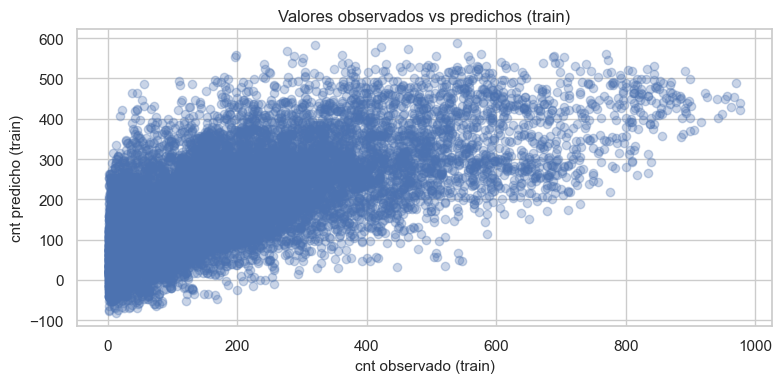

In [24]:
# Dispersión entre valores observados y predichos (entrenamiento)
fig, ax = plt.subplots()
ax.scatter(y_train, y_pred_train, alpha=0.3)
ax.set_xlabel("cnt observado (train)")
ax.set_ylabel("cnt predicho (train)")
ax.set_title("Valores observados vs predichos (train)")
plt.tight_layout()
plt.show()

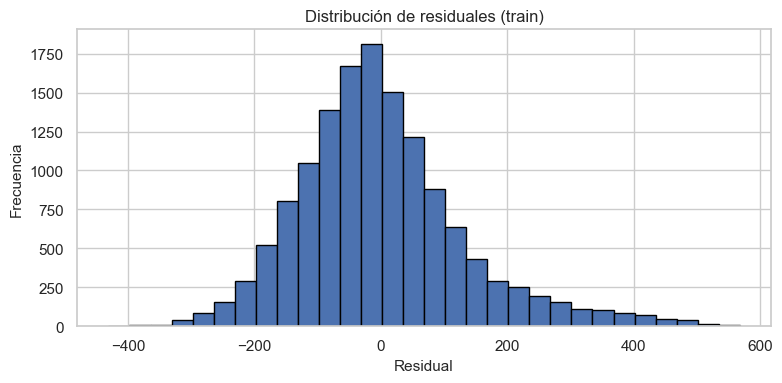

In [25]:
# Histograma de residuales en entrenamiento
residuals_train = y_train - y_pred_train
fig, ax = plt.subplots()
ax.hist(residuals_train, bins=30, edgecolor="black")
ax.set_title("Distribución de residuales (train)")
ax.set_xlabel("Residual")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 7. Resumen del capítulo

En este capítulo:

- Cargamos el dataset preparado `hour_prepared.csv`.
- Definimos la variable objetivo `cnt` y la matriz de predictores `X`.
- Dividimos los datos en conjuntos de entrenamiento y prueba.
- Ajustamos un modelo base de regresión lineal múltiple (OLS).
- Construimos una tabla de coeficientes con intervalos de confianza.
- Evaluamos el desempeño del modelo mediante RMSE y R².

En los siguientes capítulos profundizaremos en **diagnóstico del modelo**, detección de supuestos violados (normalidad, homocedasticidad, multicolinealidad) y posibles mejoras del modelo.
